In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../datasets/Video_Games_Sales_as_at_22_Dec_2016.csv")

df.head()

columns_to_keep = ['Name', 'Platform', 'Genre', 'Publisher', 'Critic_Score', 'Global_Sales', 'Rating']
df = df[columns_to_keep]

df = df.dropna()

print(f"Dataset shape: {df.shape}")

Dataset shape: (8050, 7)


Mean: 68.98
Median: 71.00
Mode: 70.00


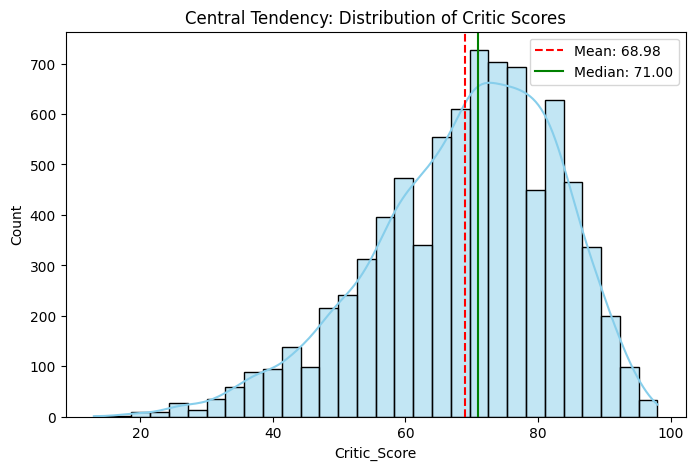

In [13]:
mean_score = df['Critic_Score'].mean()
median_score = df['Critic_Score'].median()
mode_score = df['Critic_Score'].mode()[0]

print(f"Mean: {mean_score:.2f}")
print(f"Median: {median_score:.2f}")
print(f"Mode: {mode_score:.2f}")

plt.figure(figsize=(8, 5))
sns.histplot(df['Critic_Score'], kde=True, bins=30, color='skyblue')

plt.axvline(mean_score, color='red', linestyle='--', label=f'Mean: {mean_score:.2f}')
plt.axvline(median_score, color='green', linestyle='-', label=f'Median: {median_score:.2f}')

plt.title('Central Tendency: Distribution of Critic Scores')
plt.legend()
plt.show()


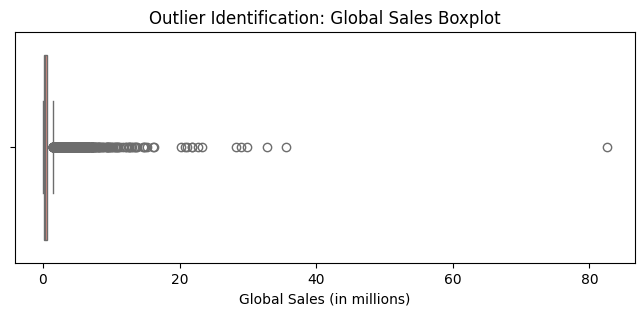

Number of Outliers detected: 831
Upper bound threshold: 1.50

Top 5 extreme outliers:
                    Name  Global_Sales
0             Wii Sports         82.53
2         Mario Kart Wii         35.52
3      Wii Sports Resort         32.77
6  New Super Mario Bros.         29.80
7               Wii Play         28.92


In [14]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['Global_Sales'], color='salmon')
plt.title('Outlier Identification: Global Sales Boxplot')
plt.xlabel('Global Sales (in millions)')
plt.show()

Q1 = df['Global_Sales'].quantile(0.25)
Q3 = df['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Global_Sales'] < lower_bound) | (df['Global_Sales'] > upper_bound)]

print(f"Number of Outliers detected: {len(outliers)}")
print(f"Upper bound threshold: {upper_bound:.2f}")
print("\nTop 5 extreme outliers:")
print(outliers.nlargest(5, 'Global_Sales')[['Name', 'Global_Sales']])

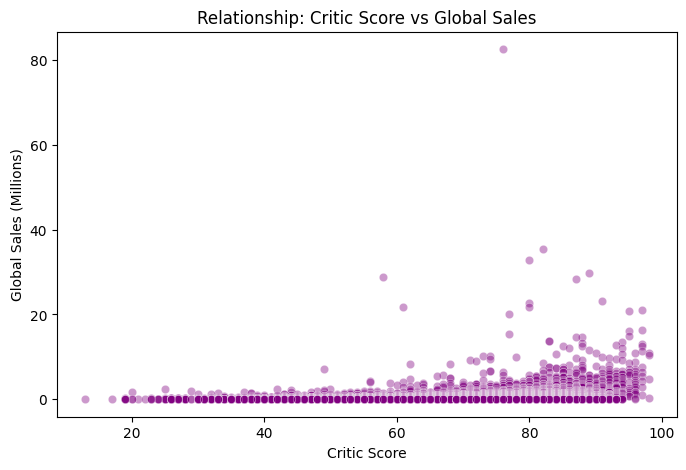

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Critic_Score', y='Global_Sales', alpha=0.4, color='purple')
plt.title('Relationship: Critic Score vs Global Sales')
plt.xlabel('Critic Score')
plt.ylabel('Global Sales (Millions)')
plt.show()

/tmp/ipykernel_33430/3276619004.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_genres, x='Genre', y='Critic_Score', palette='Set2')


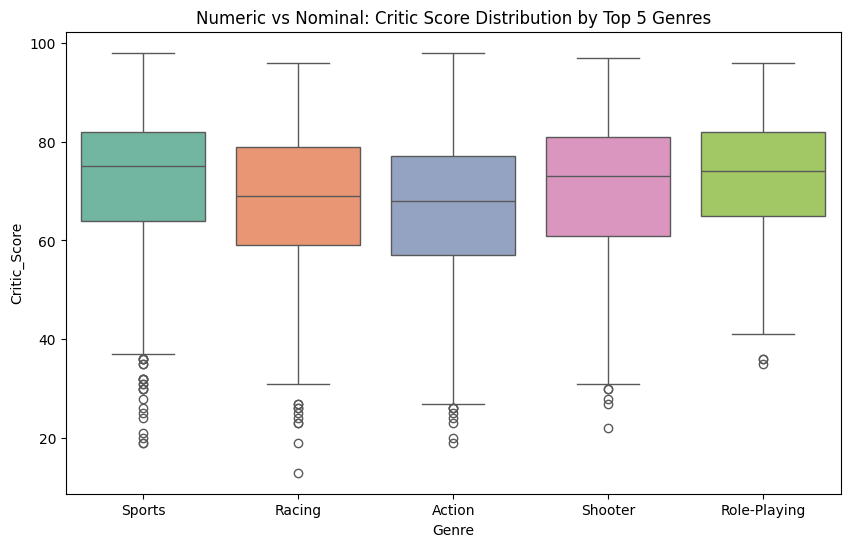

In [16]:
# 5. Visualizing relationship between numeric and nominal variable
# To keep the plot clean, let's take only the top 5 Genres by count
top_genres = df['Genre'].value_counts().index[:5]
df_top_genres = df[df['Genre'].isin(top_genres)]

plt.figure(figsize=(10, 6))
# Boxplots are fantastic for Nominal vs Numeric
sns.boxplot(data=df_top_genres, x='Genre', y='Critic_Score', palette='Set2')
plt.title('Numeric vs Nominal: Critic Score Distribution by Top 5 Genres')
plt.show()

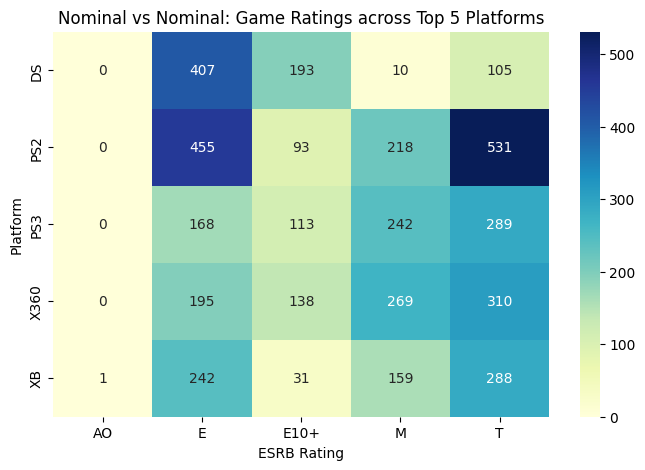

In [17]:
# 6. Visualizing relationship between two nominal variables
# Filter to view just the top 5 most frequent platforms
top_platforms = df['Platform'].value_counts().index[:5]
df_top_platforms = df[df['Platform'].isin(top_platforms)]

# Cross-tabulate Rating vs Platform
crosstab = pd.crosstab(df_top_platforms['Platform'], df_top_platforms['Rating'])

plt.figure(figsize=(8, 5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Nominal vs Nominal: Game Ratings across Top 5 Platforms')
plt.xlabel('ESRB Rating')
plt.ylabel('Platform')
plt.show()